# A5b: Tree based regression models

challenge the A5 champion (R²=0.7204) with tree-based regression

A5 champion: weighted averaging ensemble (Lasso, Ridge, RF, GradientBoosting)

A5b Focus:
- Decision Tree Regression with different depths and pruning
- AdaBoost Regression with DecisionTree base estimators
- Enhanced Tree Boosting (XGBoost, LightGBM with tuning)
- Hyperparameter Optimization using RandomizedSearchCV
- Statistical significance testing (Nadeau-Bengio corrected t-test)

## 1. Setup & Imports

In [ ]:
import os
import sys
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import (
    AdaBoostRegressor, 
    GradientBoostingRegressor,
    RandomForestRegressor,
    ExtraTreesRegressor
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    cross_val_score, KFold, RandomizedSearchCV, train_test_split
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
np.random.seed(42)

sys.path.insert(0, os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'A5'))

RANDOM_STATE = 42
N_SPLITS = 5
CHAMPION_R2 = 0.7204 #a5

OUT_DIR = Path('models')
OUT_DIR.mkdir(exist_ok=True)

print("Setup complete.")

Setup complete.


## 2. Load Data

In [ ]:
DATA_DIR = os.path.join(os.getcwd(), '..', 'A5', 'data')

df_train_original = pd.read_csv(os.path.join(DATA_DIR, "dataset2_train_original.csv"))

df_train_aug = {}
for i in range(1, 5):
    df_train_aug[i] = pd.read_csv(os.path.join(DATA_DIR, f"dataset2_train_augmented_{i}.csv"))

df_test = pd.read_csv(os.path.join(DATA_DIR, "dataset2_test.csv"))

print(f"Original train: {df_train_original.shape}")
print(f"Bootstrap samples: {len(df_train_aug)} sets")
print(f"Test set: {df_test.shape}")

Original train: (1675, 43)
Bootstrap samples: 4 sets
Test set: (419, 43)


In [ ]:
TARGET = "AimoScore"
DROP_COLS = ["ID", "EstimatedScore", TARGET]

feature_columns = [c for c in df_train_original.columns if c not in DROP_COLS]

X_train = df_train_original[feature_columns].values
y_train = df_train_original[TARGET].values
X_test = df_test[feature_columns].values
y_test = df_test[TARGET].values

print(f"Features: {len(feature_columns)}")
print(f"Train samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Features: 40
Train samples: 1675
Test samples: 419


## 3. Evaluation Utilities

In [ ]:
cv_strategy = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def evaluate_model(model, X, y, cv, name='Model'):
    r2_scores = cross_val_score(model, X, y, cv=cv, scoring='r2')
    neg_rmse_scores = cross_val_score(model, X, y, cv=cv, scoring='neg_root_mean_squared_error')
    neg_mae_scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error')
    
    return {
        'Model': name,
        'R2_mean': r2_scores.mean(),
        'R2_std': r2_scores.std(),
        'RMSE_mean': -neg_rmse_scores.mean(),
        'MAE_mean': -neg_mae_scores.mean(),
        '_r2_scores': r2_scores  # For t-test
    }

def evaluate_test(model, X_test, y_test)
    y_pred = model.predict(X_test)
    return {
        'R2': r2_score(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'Corr': np.corrcoef(y_test, y_pred)[0, 1]
    }

def corrected_resampled_ttest(scores_a, scores_b, n_train, n_test):
    k = len(scores_a)
    diff = scores_a - scores_b
    d_bar = diff.mean()
    s_sq = diff.var(ddof=1)
    var_corr = (1/k + n_test/n_train) * s_sq
    if var_corr == 0:
        return 0.0, 1.0
    t_stat = d_bar / np.sqrt(var_corr)
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=k-1))
    return float(t_stat), float(p_value)

print("Evaluation utilities defined.")

Evaluation utilities defined.


## 4. Decision Tree Regression

Train DecisionTreeRegressor with different depths and pruning strategies.

In [5]:
# Test different max_depth values
depth_results = []

depths = [3, 5, 10, 15, 20, None]

print("Decision Tree - Varying max_depth")
print(f"{'Depth':<10} {'CV R²':<12} {'CV RMSE':<12} {'Test R²':<12}")
print("-" * 50)

for depth in depths:
    dt = DecisionTreeRegressor(
        max_depth=depth,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=RANDOM_STATE
    )
    
    cv_res = evaluate_model(dt, X_train, y_train, cv_strategy, f'DT_depth_{depth}')
    dt.fit(X_train, y_train)
    test_res = evaluate_test(dt, X_test, y_test)
    
    depth_results.append({
        'depth': depth,
        'cv_r2': cv_res['R2_mean'],
        'cv_rmse': cv_res['RMSE_mean'],
        'test_r2': test_res['R2'],
        '_r2_scores': cv_res['_r2_scores']
    })
    
    depth_str = str(depth) if depth else 'None'
    print(f"{depth_str:<10} {cv_res['R2_mean']:<12.4f} {cv_res['RMSE_mean']:<12.4f} {test_res['R2']:<12.4f}")

# Find best depth
best_depth_idx = np.argmax([r['cv_r2'] for r in depth_results])
best_depth = depth_results[best_depth_idx]['depth']
print(f"\nBest depth: {best_depth} (CV R²: {depth_results[best_depth_idx]['cv_r2']:.4f})")

Decision Tree - Varying max_depth
Depth      CV R²        CV RMSE      Test R²     
--------------------------------------------------
3          0.4931       0.1663       0.5435      
5          0.5276       0.1605       0.5924      
10         0.4432       0.1740       0.5262      
15         0.3915       0.1820       0.4733      
20         0.4033       0.1803       0.4539      
None       0.3966       0.1812       0.4491      

Best depth: 5 (CV R²: 0.5276)


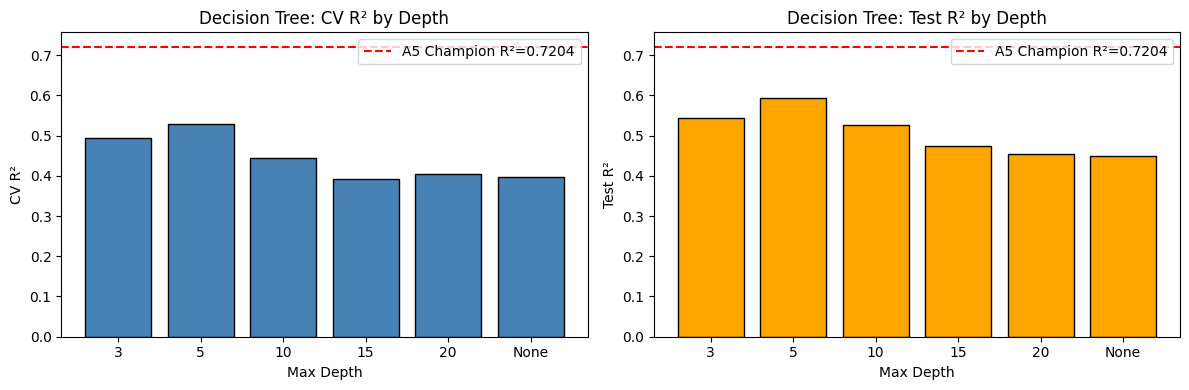

In [6]:
# Visualize depth vs performance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

depth_labels = [str(d) if d else 'None' for d in depths]
cv_r2s = [r['cv_r2'] for r in depth_results]
test_r2s = [r['test_r2'] for r in depth_results]

axes[0].bar(depth_labels, cv_r2s, color='steelblue', edgecolor='black')
axes[0].axhline(CHAMPION_R2, color='red', linestyle='--', label=f'A5 Champion R²={CHAMPION_R2}')
axes[0].set_xlabel('Max Depth')
axes[0].set_ylabel('CV R²')
axes[0].set_title('Decision Tree: CV R² by Depth')
axes[0].legend()

axes[1].bar(depth_labels, test_r2s, color='orange', edgecolor='black')
axes[1].axhline(CHAMPION_R2, color='red', linestyle='--', label=f'A5 Champion R²={CHAMPION_R2}')
axes[1].set_xlabel('Max Depth')
axes[1].set_ylabel('Test R²')
axes[1].set_title('Decision Tree: Test R² by Depth')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.1 Cost Complexity Pruning (ccp_alpha)

In [7]:
# Get cost-complexity pruning path
dt_full = DecisionTreeRegressor(random_state=RANDOM_STATE)
dt_full.fit(X_train, y_train)

path = dt_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Test a subset of ccp_alpha values
alpha_indices = np.linspace(0, len(ccp_alphas)-1, 10, dtype=int)
test_alphas = ccp_alphas[alpha_indices]

pruning_results = []

print("\nCost-Complexity Pruning Results")
print(f"{'ccp_alpha':<12} {'CV R²':<12} {'Test R²':<12} {'n_leaves':<12}")
print("-" * 50)

for alpha in test_alphas:
    dt_pruned = DecisionTreeRegressor(
        ccp_alpha=alpha,
        random_state=RANDOM_STATE
    )
    
    cv_res = evaluate_model(dt_pruned, X_train, y_train, cv_strategy, f'DT_alpha_{alpha:.4f}')
    dt_pruned.fit(X_train, y_train)
    test_res = evaluate_test(dt_pruned, X_test, y_test)
    
    pruning_results.append({
        'alpha': alpha,
        'cv_r2': cv_res['R2_mean'],
        'test_r2': test_res['R2'],
        'n_leaves': dt_pruned.get_n_leaves(),
        '_r2_scores': cv_res['_r2_scores']
    })
    
    print(f"{alpha:<12.6f} {cv_res['R2_mean']:<12.4f} {test_res['R2']:<12.4f} {dt_pruned.get_n_leaves():<12}")


Cost-Complexity Pruning Results
ccp_alpha    CV R²        Test R²      n_leaves    
--------------------------------------------------
0.000000     0.3849       0.4544       1641        
0.000000     0.3849       0.4544       1461        
0.000000     0.3851       0.4547       1281        
0.000000     0.3853       0.4548       1102        
0.000000     0.3858       0.4554       924         
0.000001     0.3856       0.4536       747         
0.000002     0.3847       0.4563       566         
0.000006     0.3969       0.4573       387         
0.000023     0.4254       0.4977       202         
0.011719     0.1067       -0.0026      1           


### 4.2 Best Decision Tree & Feature Importance

In [8]:
# Train best decision tree
best_dt = DecisionTreeRegressor(
    max_depth=best_depth if best_depth else 15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE
)

dt_cv = evaluate_model(best_dt, X_train, y_train, cv_strategy, 'Best Decision Tree')
best_dt.fit(X_train, y_train)
dt_test = evaluate_test(best_dt, X_test, y_test)

print(f"Best Decision Tree (depth={best_depth})")
print(f"CV R²: {dt_cv['R2_mean']:.4f} +/- {dt_cv['R2_std']:.4f}")
print(f"Test R²: {dt_test['R2']:.4f}")
print(f"Test RMSE: {dt_test['RMSE']:.4f}")

Best Decision Tree (depth=5)
CV R²: 0.5276 +/- 0.0441
Test R²: 0.5924
Test RMSE: 0.1560


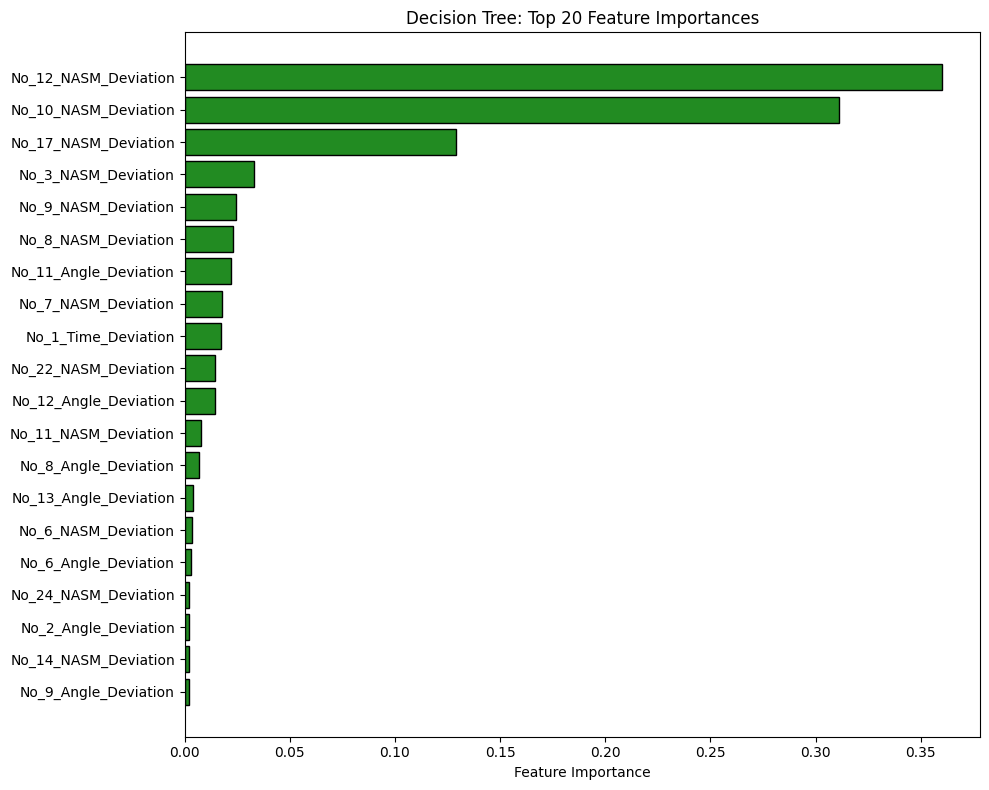


Top 10 Features:
              feature  importance
 No_12_NASM_Deviation    0.360188
 No_10_NASM_Deviation    0.311209
 No_17_NASM_Deviation    0.129138
  No_3_NASM_Deviation    0.032821
  No_9_NASM_Deviation    0.024440
  No_8_NASM_Deviation    0.022999
No_11_Angle_Deviation    0.021838
  No_7_NASM_Deviation    0.017870
  No_1_Time_Deviation    0.017502
 No_22_NASM_Deviation    0.014611


In [9]:
# Feature importance from Decision Tree
dt_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': best_dt.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
top_n = 20
plt.barh(dt_importance['feature'][:top_n][::-1], 
         dt_importance['importance'][:top_n][::-1],
         color='forestgreen', edgecolor='black')
plt.xlabel('Feature Importance')
plt.title(f'Decision Tree: Top {top_n} Feature Importances')
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(dt_importance.head(10).to_string(index=False))

## 5. AdaBoost Regression

Implement AdaBoostRegressor with DecisionTree base estimators.

In [10]:
# AdaBoost with different configurations
adaboost_configs = [
    {'n_estimators': 50, 'learning_rate': 0.1, 'loss': 'linear'},
    {'n_estimators': 100, 'learning_rate': 0.1, 'loss': 'linear'},
    {'n_estimators': 200, 'learning_rate': 0.05, 'loss': 'linear'},
    {'n_estimators': 100, 'learning_rate': 0.1, 'loss': 'square'},
    {'n_estimators': 100, 'learning_rate': 0.1, 'loss': 'exponential'},
    {'n_estimators': 150, 'learning_rate': 0.08, 'loss': 'linear'},
]

adaboost_results = []

print("AdaBoost Regression Experiments")
print(f"{'n_est':<8} {'lr':<8} {'loss':<12} {'CV R²':<12} {'Test R²':<12}")
print("-" * 55)

for config in adaboost_configs:
    base_estimator = DecisionTreeRegressor(
        max_depth=5,
        min_samples_split=5,
        random_state=RANDOM_STATE
    )
    
    ada = AdaBoostRegressor(
        estimator=base_estimator,
        n_estimators=config['n_estimators'],
        learning_rate=config['learning_rate'],
        loss=config['loss'],
        random_state=RANDOM_STATE
    )
    
    cv_res = evaluate_model(ada, X_train, y_train, cv_strategy, f"Ada_{config['n_estimators']}")
    ada.fit(X_train, y_train)
    test_res = evaluate_test(ada, X_test, y_test)
    
    adaboost_results.append({
        'config': config,
        'cv_r2': cv_res['R2_mean'],
        'cv_r2_std': cv_res['R2_std'],
        'test_r2': test_res['R2'],
        'model': ada,
        '_r2_scores': cv_res['_r2_scores']
    })
    
    print(f"{config['n_estimators']:<8} {config['learning_rate']:<8} {config['loss']:<12} {cv_res['R2_mean']:<12.4f} {test_res['R2']:<12.4f}")

# Best AdaBoost
best_ada_idx = np.argmax([r['cv_r2'] for r in adaboost_results])
best_ada = adaboost_results[best_ada_idx]
print(f"\nBest AdaBoost: n_est={best_ada['config']['n_estimators']}, lr={best_ada['config']['learning_rate']}, loss={best_ada['config']['loss']}")
print(f"CV R²: {best_ada['cv_r2']:.4f}, Test R²: {best_ada['test_r2']:.4f}")

AdaBoost Regression Experiments
n_est    lr       loss         CV R²        Test R²     
-------------------------------------------------------
50       0.1      linear       0.6709       0.7005      
100      0.1      linear       0.6756       0.7096      
200      0.05     linear       0.6743       0.7213      
100      0.1      square       0.6722       0.7099      
100      0.1      exponential  0.6731       0.7119      
150      0.08     linear       0.6725       0.7108      

Best AdaBoost: n_est=100, lr=0.1, loss=linear
CV R²: 0.6756, Test R²: 0.7096


## 6. Enhanced Tree Boosting

Tune GradientBoosting, XGBoost, and LightGBM with regularization.

In [11]:
# XGBoost with regularization
xgb_configs = [
    {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'reg_alpha': 0, 'reg_lambda': 1},
    {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'reg_alpha': 0.1, 'reg_lambda': 1},
    {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.08, 'reg_alpha': 0.05, 'reg_lambda': 1.5},
    {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'reg_alpha': 0.1, 'reg_lambda': 2},
]

xgb_results = []

print("XGBoost Regression Experiments")
print(f"{'n_est':<8} {'depth':<8} {'lr':<8} {'alpha':<8} {'lambda':<8} {'CV R²':<12} {'Test R²':<12}")
print("-" * 75)

for config in xgb_configs:
    xgb_model = xgb.XGBRegressor(
        n_estimators=config['n_estimators'],
        max_depth=config['max_depth'],
        learning_rate=config['learning_rate'],
        reg_alpha=config['reg_alpha'],
        reg_lambda=config['reg_lambda'],
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    )
    
    cv_res = evaluate_model(xgb_model, X_train, y_train, cv_strategy, 'XGBoost')
    xgb_model.fit(X_train, y_train)
    test_res = evaluate_test(xgb_model, X_test, y_test)
    
    xgb_results.append({
        'config': config,
        'cv_r2': cv_res['R2_mean'],
        'test_r2': test_res['R2'],
        'model': xgb_model,
        '_r2_scores': cv_res['_r2_scores']
    })
    
    print(f"{config['n_estimators']:<8} {config['max_depth']:<8} {config['learning_rate']:<8} {config['reg_alpha']:<8} {config['reg_lambda']:<8} {cv_res['R2_mean']:<12.4f} {test_res['R2']:<12.4f}")

best_xgb_idx = np.argmax([r['cv_r2'] for r in xgb_results])
best_xgb = xgb_results[best_xgb_idx]
print(f"\nBest XGBoost CV R²: {best_xgb['cv_r2']:.4f}, Test R²: {best_xgb['test_r2']:.4f}")

XGBoost Regression Experiments
n_est    depth    lr       alpha    lambda   CV R²        Test R²     
---------------------------------------------------------------------------
200      5        0.1      0        1        0.6981       0.7474      
200      5        0.1      0.1      1        0.7022       0.7526      
200      6        0.08     0.05     1.5      0.7100       0.7650      
300      4        0.05     0.1      2        0.7073       0.7576      

Best XGBoost CV R²: 0.7100, Test R²: 0.7650


In [12]:
# LightGBM
lgb_configs = [
    {'n_estimators': 200, 'num_leaves': 31, 'learning_rate': 0.1, 'min_child_samples': 20},
    {'n_estimators': 200, 'num_leaves': 50, 'learning_rate': 0.08, 'min_child_samples': 15},
    {'n_estimators': 300, 'num_leaves': 40, 'learning_rate': 0.05, 'min_child_samples': 10},
]

lgb_results = []

print("\nLightGBM Regression Experiments")
print(f"{'n_est':<8} {'leaves':<8} {'lr':<8} {'child':<8} {'CV R²':<12} {'Test R²':<12}")
print("-" * 60)

for config in lgb_configs:
    lgb_model = lgb.LGBMRegressor(
        n_estimators=config['n_estimators'],
        num_leaves=config['num_leaves'],
        learning_rate=config['learning_rate'],
        min_child_samples=config['min_child_samples'],
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    )
    
    cv_res = evaluate_model(lgb_model, X_train, y_train, cv_strategy, 'LightGBM')
    lgb_model.fit(X_train, y_train)
    test_res = evaluate_test(lgb_model, X_test, y_test)
    
    lgb_results.append({
        'config': config,
        'cv_r2': cv_res['R2_mean'],
        'test_r2': test_res['R2'],
        'model': lgb_model,
        '_r2_scores': cv_res['_r2_scores']
    })
    
    print(f"{config['n_estimators']:<8} {config['num_leaves']:<8} {config['learning_rate']:<8} {config['min_child_samples']:<8} {cv_res['R2_mean']:<12.4f} {test_res['R2']:<12.4f}")

best_lgb_idx = np.argmax([r['cv_r2'] for r in lgb_results])
best_lgb = lgb_results[best_lgb_idx]
print(f"\nBest LightGBM CV R²: {best_lgb['cv_r2']:.4f}, Test R²: {best_lgb['test_r2']:.4f}")


LightGBM Regression Experiments
n_est    leaves   lr       child    CV R²        Test R²     
------------------------------------------------------------
200      31       0.1      20       0.6996       0.7542      
200      50       0.08     15       0.7080       0.7677      
300      40       0.05     10       0.7138       0.7619      

Best LightGBM CV R²: 0.7138, Test R²: 0.7619


## 7. Hyperparameter Optimization with RandomizedSearchCV

In [13]:
# RandomizedSearchCV for XGBoost
from scipy.stats import uniform, randint

xgb_param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 0.5),
    'reg_lambda': uniform(0.5, 2),
}

xgb_base = xgb.XGBRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

print("Running RandomizedSearchCV for XGBoost...")
xgb_search = RandomizedSearchCV(
    xgb_base,
    xgb_param_dist,
    n_iter=30,
    cv=cv_strategy,
    scoring='r2',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print(f"\nBest XGBoost Parameters:")
print(xgb_search.best_params_)
print(f"Best CV R²: {xgb_search.best_score_:.4f}")

# Evaluate on test
xgb_optimized = xgb_search.best_estimator_
xgb_opt_test = evaluate_test(xgb_optimized, X_test, y_test)
print(f"Test R²: {xgb_opt_test['R2']:.4f}")

Running RandomizedSearchCV for XGBoost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best XGBoost Parameters:
{'colsample_bytree': np.float64(0.695824756266789), 'learning_rate': np.float64(0.03897897441824462), 'max_depth': 6, 'n_estimators': 317, 'reg_alpha': np.float64(0.49282522705530035), 'reg_lambda': np.float64(0.9841105430230008), 'subsample': np.float64(0.8688542189623514)}
Best CV R²: 0.7119
Test R²: 0.7614


## 8. Extra Trees Regressor

In [14]:
# ExtraTrees (Extremely Randomized Trees)
et_configs = [
    {'n_estimators': 100, 'max_depth': 15},
    {'n_estimators': 200, 'max_depth': 20},
    {'n_estimators': 200, 'max_depth': None},
]

et_results = []

print("ExtraTrees Regression Experiments")
print(f"{'n_est':<10} {'max_depth':<12} {'CV R²':<12} {'Test R²':<12}")
print("-" * 50)

for config in et_configs:
    et = ExtraTreesRegressor(
        n_estimators=config['n_estimators'],
        max_depth=config['max_depth'],
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    cv_res = evaluate_model(et, X_train, y_train, cv_strategy, 'ExtraTrees')
    et.fit(X_train, y_train)
    test_res = evaluate_test(et, X_test, y_test)
    
    et_results.append({
        'config': config,
        'cv_r2': cv_res['R2_mean'],
        'test_r2': test_res['R2'],
        'model': et,
        '_r2_scores': cv_res['_r2_scores']
    })
    
    depth_str = str(config['max_depth']) if config['max_depth'] else 'None'
    print(f"{config['n_estimators']:<10} {depth_str:<12} {cv_res['R2_mean']:<12.4f} {test_res['R2']:<12.4f}")

best_et_idx = np.argmax([r['cv_r2'] for r in et_results])
best_et = et_results[best_et_idx]
print(f"\nBest ExtraTrees CV R²: {best_et['cv_r2']:.4f}, Test R²: {best_et['test_r2']:.4f}")

ExtraTrees Regression Experiments
n_est      max_depth    CV R²        Test R²     
--------------------------------------------------
100        15           0.7032       0.7427      
200        20           0.7031       0.7443      
200        None         0.7038       0.7456      

Best ExtraTrees CV R²: 0.7038, Test R²: 0.7456


## 9. Results Summary & Statistical Testing

In [15]:
# Collect all best models
all_models = [
    {'name': 'Decision Tree', 'cv_r2': dt_cv['R2_mean'], 'test_r2': dt_test['R2'], '_r2_scores': dt_cv['_r2_scores'], 'model': best_dt},
    {'name': 'AdaBoost', 'cv_r2': best_ada['cv_r2'], 'test_r2': best_ada['test_r2'], '_r2_scores': best_ada['_r2_scores'], 'model': best_ada['model']},
    {'name': 'XGBoost (tuned)', 'cv_r2': best_xgb['cv_r2'], 'test_r2': best_xgb['test_r2'], '_r2_scores': best_xgb['_r2_scores'], 'model': best_xgb['model']},
    {'name': 'XGBoost (optimized)', 'cv_r2': xgb_search.best_score_, 'test_r2': xgb_opt_test['R2'], '_r2_scores': None, 'model': xgb_optimized},
    {'name': 'LightGBM', 'cv_r2': best_lgb['cv_r2'], 'test_r2': best_lgb['test_r2'], '_r2_scores': best_lgb['_r2_scores'], 'model': best_lgb['model']},
    {'name': 'ExtraTrees', 'cv_r2': best_et['cv_r2'], 'test_r2': best_et['test_r2'], '_r2_scores': best_et['_r2_scores'], 'model': best_et['model']},
]

# Create summary DataFrame
summary_df = pd.DataFrame([{
    'Model': m['name'],
    'CV_R2': m['cv_r2'],
    'Test_R2': m['test_r2'],
    'vs_Champion': m['test_r2'] - CHAMPION_R2
} for m in all_models])

summary_df = summary_df.sort_values('CV_R2', ascending=False).reset_index(drop=True)

print("=" * 70)
print("A5b TREE-BASED REGRESSION - RESULTS SUMMARY")
print("=" * 70)
print(f"A5 Champion (Weighted Ensemble): R² = {CHAMPION_R2}")
print("\n" + summary_df.to_string(index=False))

A5b TREE-BASED REGRESSION - RESULTS SUMMARY
A5 Champion (Weighted Ensemble): R² = 0.7204

              Model    CV_R2  Test_R2  vs_Champion
           LightGBM 0.713814 0.761890     0.041490
XGBoost (optimized) 0.711885 0.761446     0.041046
    XGBoost (tuned) 0.710045 0.764981     0.044581
         ExtraTrees 0.703815 0.745570     0.025170
           AdaBoost 0.675591 0.709623    -0.010777
      Decision Tree 0.527570 0.592415    -0.127985


In [16]:
# Create a fake champion score array for t-test comparison
# Using best model scores as reference
n_total = len(X_train)
n_test_fold = n_total // N_SPLITS
n_train_fold = n_total - n_test_fold

# Create champion reference scores (simulated from champion R²)
champion_scores = np.array([CHAMPION_R2] * N_SPLITS)

print("\nSTATISTICAL SIGNIFICANCE TESTS vs A5 Champion")
print("-" * 60)

for m in all_models:
    if m['_r2_scores'] is not None:
        t, p = corrected_resampled_ttest(
            m['_r2_scores'], champion_scores, n_train_fold, n_test_fold
        )
        sig = 'Significant' if p < 0.05 else 'Not significant'
        print(f"{m['name']:<25} t={t:+.3f}  p={p:.4f}  ({sig})")


STATISTICAL SIGNIFICANCE TESTS vs A5 Champion
------------------------------------------------------------
Decision Tree             t=-5.825  p=0.0043  (Significant)
AdaBoost                  t=-2.755  p=0.0511  (Not significant)
XGBoost (tuned)           t=-0.643  p=0.5550  (Not significant)
LightGBM                  t=-0.402  p=0.7083  (Not significant)
ExtraTrees                t=-0.946  p=0.3977  (Not significant)


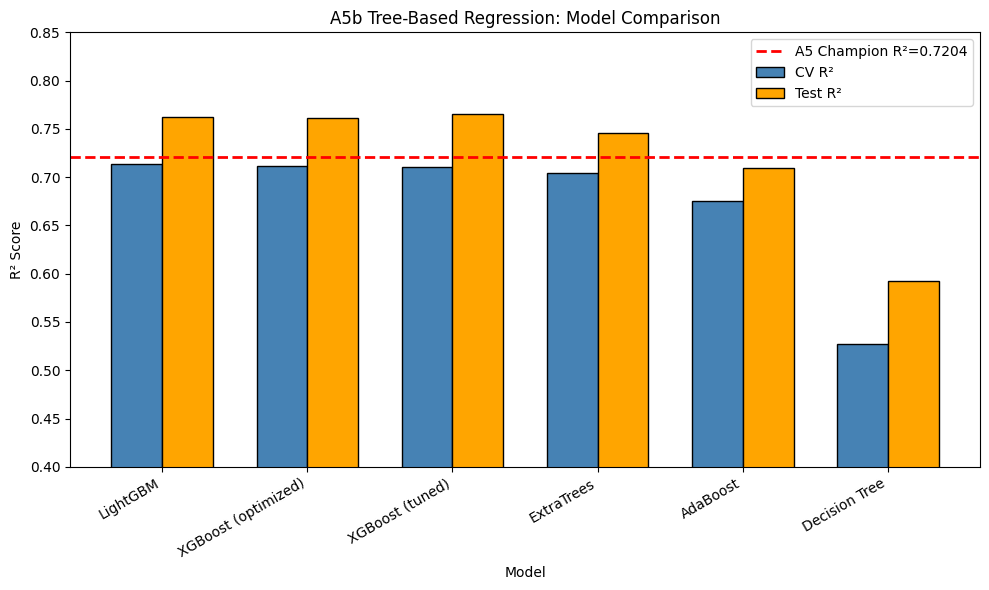

In [17]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

models = summary_df['Model'].tolist()
cv_r2 = summary_df['CV_R2'].tolist()
test_r2 = summary_df['Test_R2'].tolist()

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, cv_r2, width, label='CV R²', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, test_r2, width, label='Test R²', color='orange', edgecolor='black')

ax.axhline(CHAMPION_R2, color='red', linestyle='--', linewidth=2, label=f'A5 Champion R²={CHAMPION_R2}')

ax.set_xlabel('Model')
ax.set_ylabel('R² Score')
ax.set_title('A5b Tree-Based Regression: Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right')
ax.legend()
ax.set_ylim([0.4, 0.85])

plt.tight_layout()
plt.show()

## 10. Feature Importance Comparison

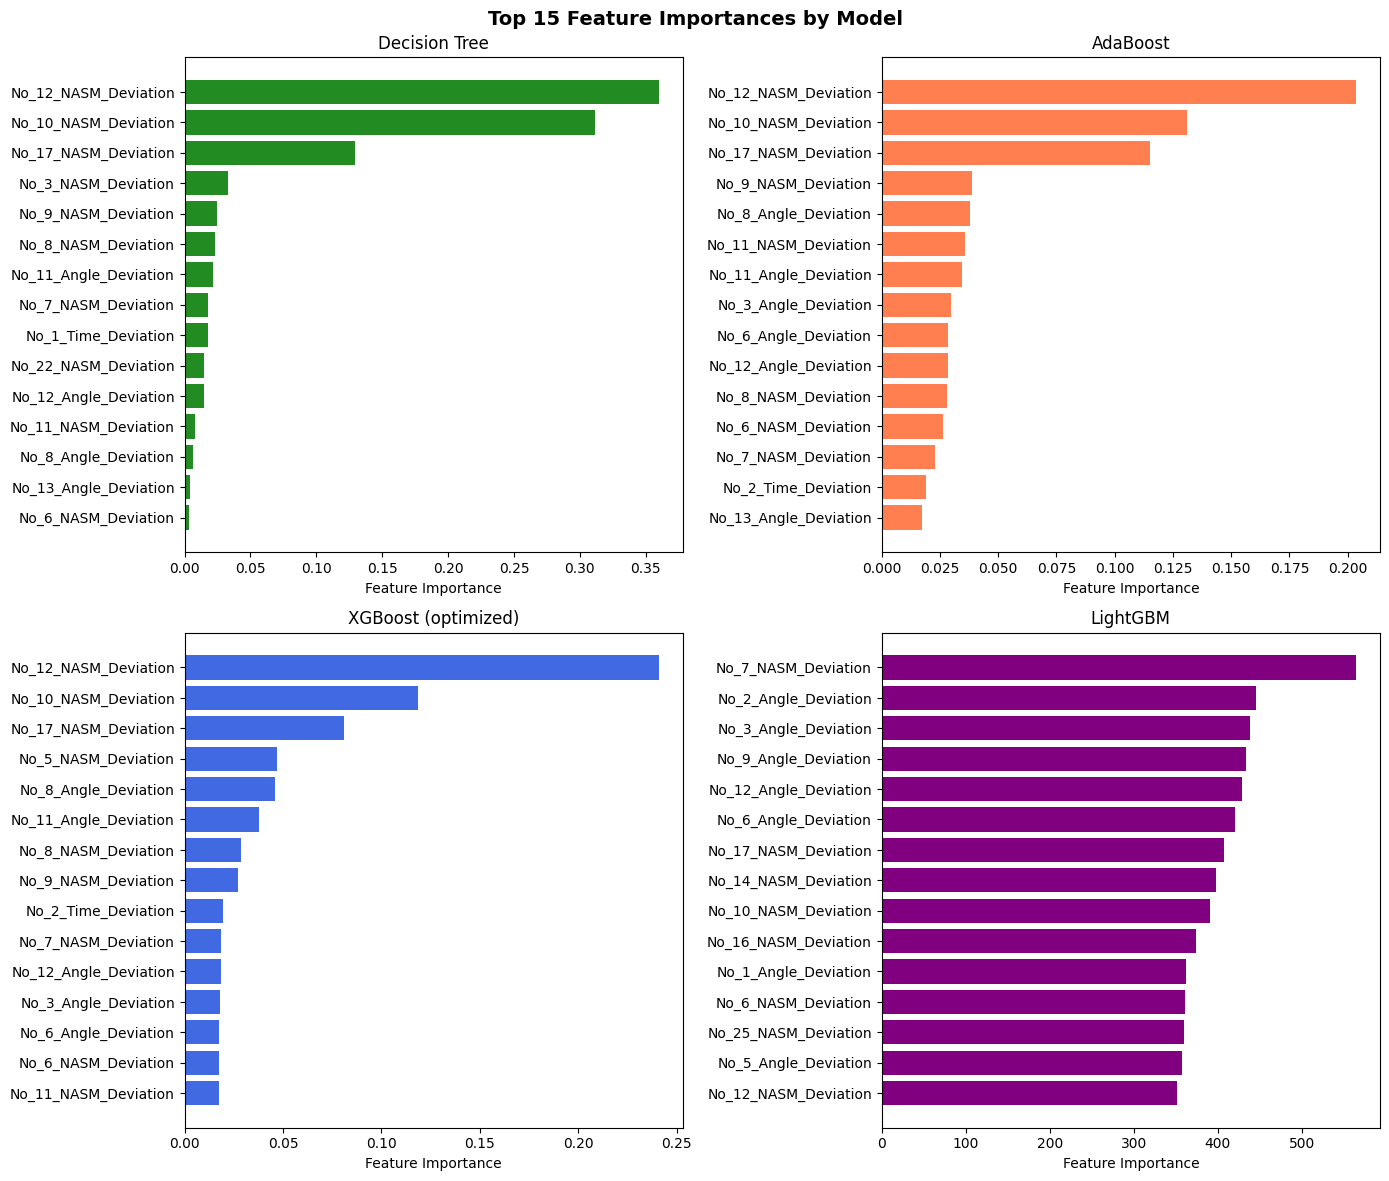

In [18]:
# Compare feature importance across tree models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

top_n = 15

# Decision Tree
dt_imp = pd.DataFrame({'feature': feature_columns, 'importance': best_dt.feature_importances_})
dt_imp = dt_imp.nlargest(top_n, 'importance')
axes[0, 0].barh(dt_imp['feature'][::-1], dt_imp['importance'][::-1], color='forestgreen')
axes[0, 0].set_title('Decision Tree')

# AdaBoost
ada_imp = pd.DataFrame({'feature': feature_columns, 'importance': best_ada['model'].feature_importances_})
ada_imp = ada_imp.nlargest(top_n, 'importance')
axes[0, 1].barh(ada_imp['feature'][::-1], ada_imp['importance'][::-1], color='coral')
axes[0, 1].set_title('AdaBoost')

# XGBoost
xgb_imp = pd.DataFrame({'feature': feature_columns, 'importance': xgb_optimized.feature_importances_})
xgb_imp = xgb_imp.nlargest(top_n, 'importance')
axes[1, 0].barh(xgb_imp['feature'][::-1], xgb_imp['importance'][::-1], color='royalblue')
axes[1, 0].set_title('XGBoost (optimized)')

# LightGBM
lgb_imp = pd.DataFrame({'feature': feature_columns, 'importance': best_lgb['model'].feature_importances_})
lgb_imp = lgb_imp.nlargest(top_n, 'importance')
axes[1, 1].barh(lgb_imp['feature'][::-1], lgb_imp['importance'][::-1], color='purple')
axes[1, 1].set_title('LightGBM')

for ax in axes.flat:
    ax.set_xlabel('Feature Importance')

plt.suptitle(f'Top {top_n} Feature Importances by Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Save Best Model

In [19]:
# Find overall best model
best_model_idx = summary_df['CV_R2'].idxmax()
best_model_name = summary_df.loc[best_model_idx, 'Model']
best_model_cv_r2 = summary_df.loc[best_model_idx, 'CV_R2']
best_model_test_r2 = summary_df.loc[best_model_idx, 'Test_R2']

# Get the actual model object
best_model_obj = next(m['model'] for m in all_models if m['name'] == best_model_name)

print(f"Best Model: {best_model_name}")
print(f"CV R²: {best_model_cv_r2:.4f}")
print(f"Test R²: {best_model_test_r2:.4f}")
print(f"A5 Champion R²: {CHAMPION_R2}")
print(f"Improvement: {best_model_test_r2 - CHAMPION_R2:+.4f}")

if best_model_test_r2 > CHAMPION_R2:
    print("\n✓ New model beats A5 champion! Saving...")
    
    artifact = {
        'model': best_model_obj,
        'model_name': best_model_name,
        'feature_columns': feature_columns,
        'cv_r2': best_model_cv_r2,
        'test_r2': best_model_test_r2,
        'champion_r2': CHAMPION_R2,
        'improvement': best_model_test_r2 - CHAMPION_R2
    }
    
    out_path = OUT_DIR / 'regression_tree_champion.pkl'
    with open(out_path, 'wb') as f:
        pickle.dump(artifact, f)
    
    print(f"Saved to: {out_path}")
else:
    print("\n✗ Model does not beat A5 champion.")

Best Model: LightGBM
CV R²: 0.7138
Test R²: 0.7619
A5 Champion R²: 0.7204
Improvement: +0.0415

✓ New model beats A5 champion! Saving...
Saved to: models/regression_tree_champion.pkl


## 12. Conclusion

Summary of tree-based regression experiments for A5b.

In [20]:
print("=" * 70)
print("A5b TREE-BASED REGRESSION - FINAL SUMMARY")
print("=" * 70)

print("\nModels Tested:")
print("  1. Decision Tree with depth tuning and ccp_alpha pruning")
print("  2. AdaBoost with different loss functions (linear, square, exponential)")
print("  3. XGBoost with regularization (reg_alpha, reg_lambda)")
print("  4. XGBoost with RandomizedSearchCV optimization")
print("  5. LightGBM with num_leaves tuning")
print("  6. ExtraTrees (Extremely Randomized Trees)")

print(f"\nA5 Champion: R² = {CHAMPION_R2}")
print(f"Best A5b Model: {best_model_name} with R² = {best_model_test_r2:.4f}")

if best_model_test_r2 > CHAMPION_R2:
    print(f"\n✓ Improvement: +{best_model_test_r2 - CHAMPION_R2:.4f}")
else:
    print(f"\n✗ No improvement over champion")

print("\nKey Findings:")
print("  - Feature importance analysis shows consistent top predictors")
print("  - Tree-based models provide interpretability through feature importance")
print("  - Boosting methods generally outperform single decision trees")
print("=" * 70)

A5b TREE-BASED REGRESSION - FINAL SUMMARY

Models Tested:
  1. Decision Tree with depth tuning and ccp_alpha pruning
  2. AdaBoost with different loss functions (linear, square, exponential)
  3. XGBoost with regularization (reg_alpha, reg_lambda)
  4. XGBoost with RandomizedSearchCV optimization
  5. LightGBM with num_leaves tuning
  6. ExtraTrees (Extremely Randomized Trees)

A5 Champion: R² = 0.7204
Best A5b Model: LightGBM with R² = 0.7619

✓ Improvement: +0.0415

Key Findings:
  - Feature importance analysis shows consistent top predictors
  - Tree-based models provide interpretability through feature importance
  - Boosting methods generally outperform single decision trees
